# DASIT Sreen Figures



In [1]:
import sys
sys.executable


'/home/hcevasco/.conda/envs/analysis_env/bin/python'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import warnings
import os
import functools
import upsetplot
import sklearn
from pathlib import Path
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
plt.rcParams['figure.dpi'] = 300

from pathlib import Path

PROJECT_ROOT = Path().resolve()
OUTDIR = PROJECT_ROOT 
OUTDIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore')


# Skew ratios
## Calculate the 90:10 skew ratios
This uses the raw counts to calculate the ratio between the 90th and 10th percentile guides and ideally for in vitro screens this should be < 10 to show there's no massive shift in one direction 

In [3]:
def compute_skew_df(count_df, condition_label):
    """
    count_df: dataframe with sgRNAs as rows, samples as columns
    condition_label: 'puro' or 'noPuro'
    """
    records = []

    for sample in count_df.columns:
        d = np.sort(count_df[sample].to_numpy())
        ten = int(0.1 * len(d))
        ninety = int(0.9 * len(d))

        skew = d[ninety] / d[ten]

        # extract timepoint from sample name
        timepoint = (
            pd.Series(sample)
            .str.extract("(d0|d5|d15)", expand=False)
            .str.upper()
            .iloc[0]
        )

        records.append({
            "Sample": sample,
            "Timepoint": timepoint,
            "90/10 Skew Ratio": skew,
            "Condition": condition_label
        })

    return pd.DataFrame(records)


In [4]:
puro_counts = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t")
noPuro_counts = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t")

# drop sgRNA + gene columns
puro_counts = puro_counts.iloc[:, 2:]
noPuro_counts = noPuro_counts.iloc[:, 2:]

puro_skew_df = compute_skew_df(puro_counts, "puro")
noPuro_skew_df = compute_skew_df(noPuro_counts, "noPuro")

skew_df = pd.concat([noPuro_skew_df, puro_skew_df], ignore_index=True)

order = ["D0", "D5", "D15"]


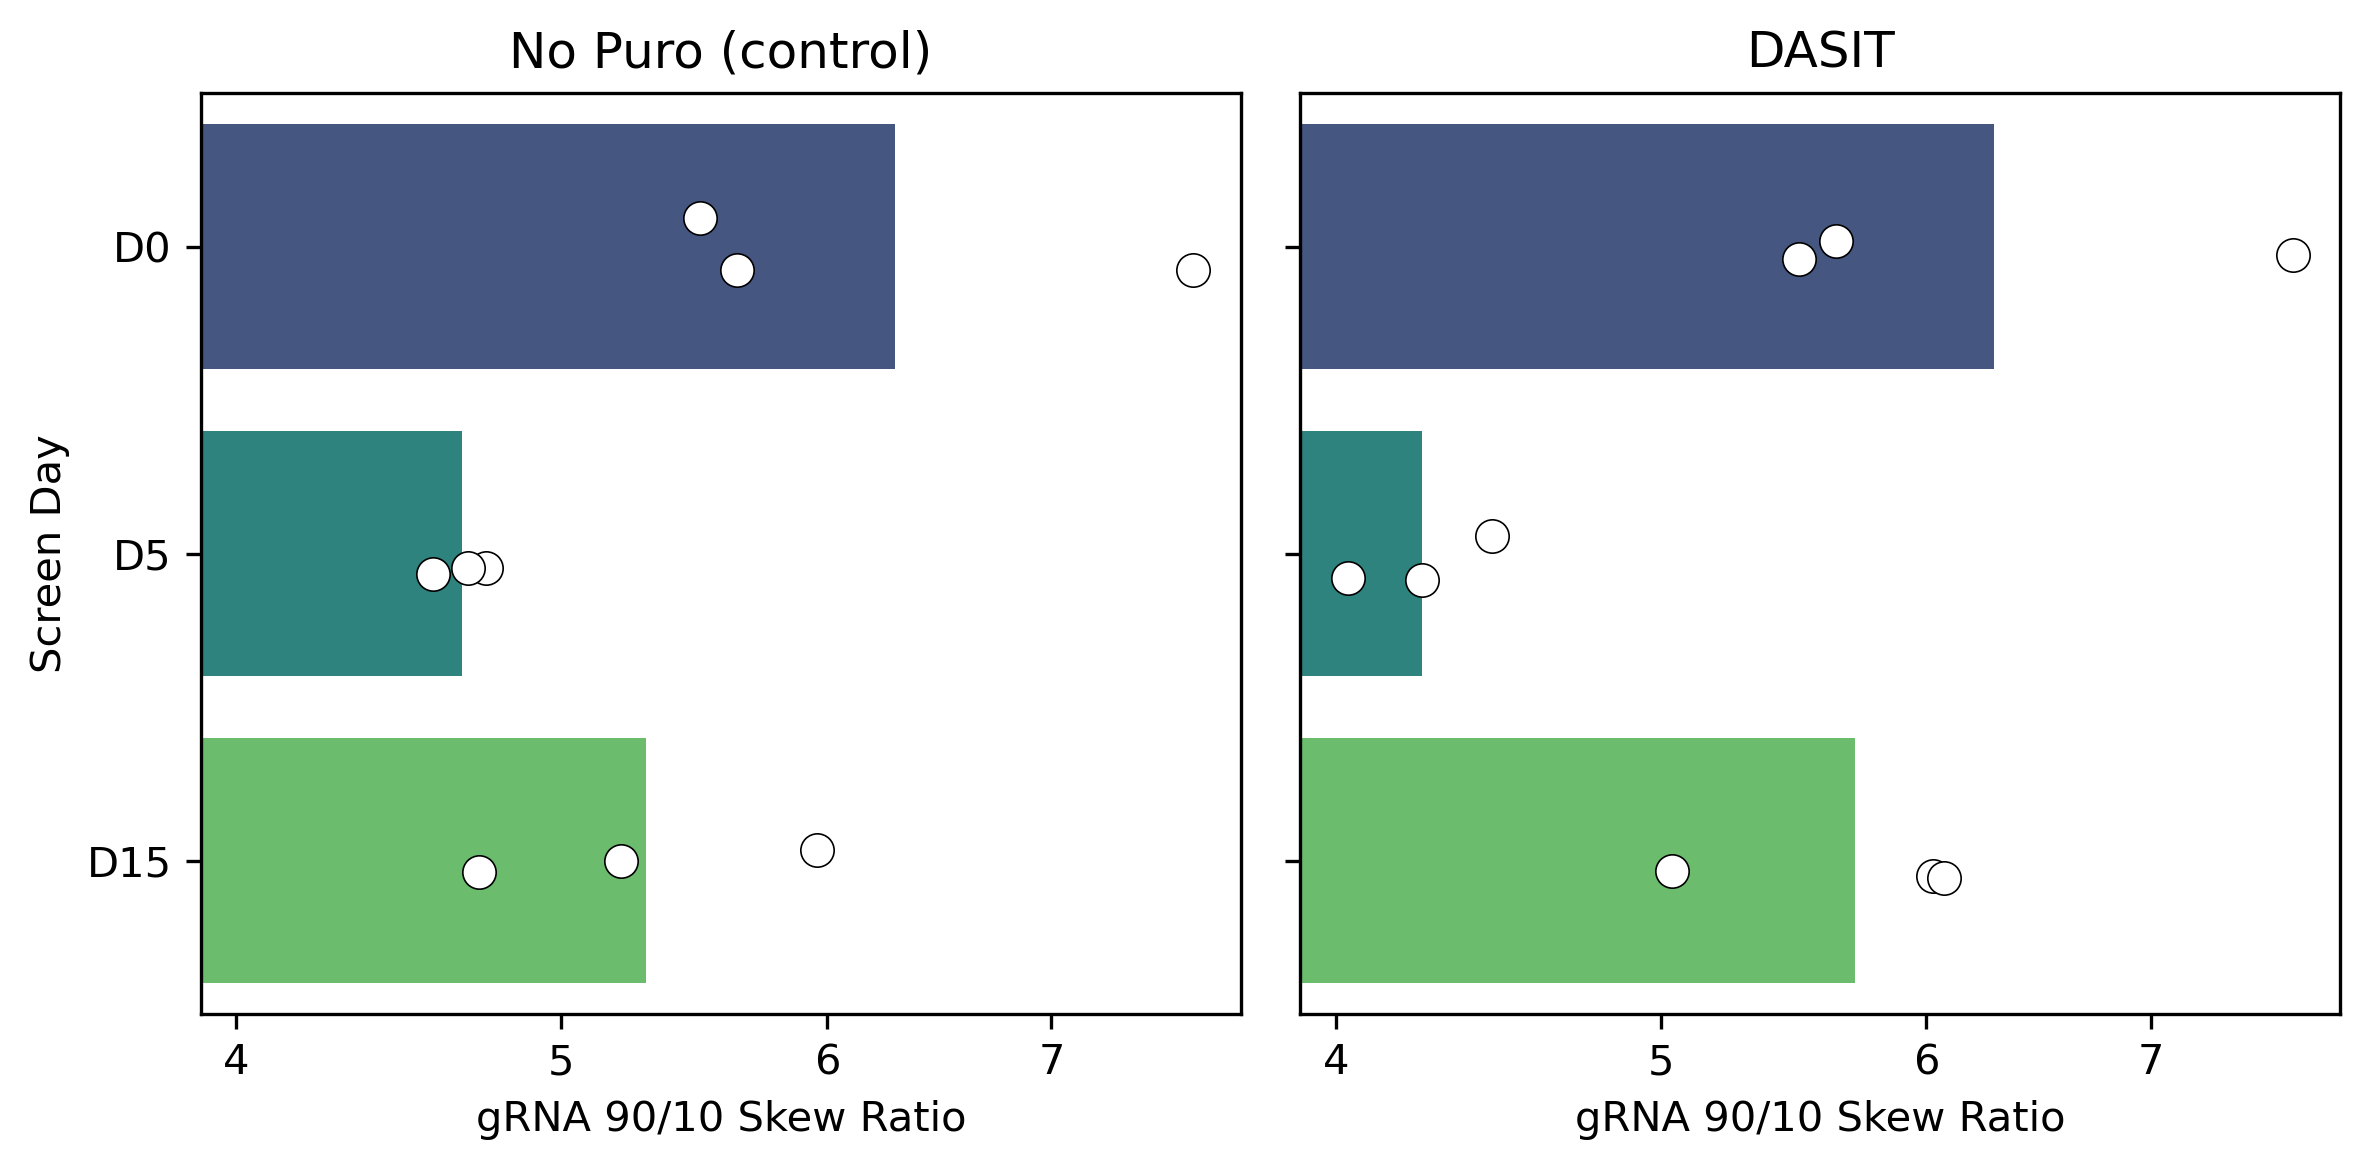

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)
palette = 'viridis'


sns.barplot(
    data=skew_df[skew_df.Condition == "noPuro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[0],
    palette=palette,
    ci=None
)

sns.stripplot(
    data=skew_df[skew_df.Condition == "noPuro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[0],
    color='white',
    edgecolor='black',
    linewidth=0.4,
    size=8
)

sns.barplot(
    data=skew_df[skew_df.Condition == "puro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[1],
    palette=palette,
    ci=None
)

sns.stripplot(
    data=skew_df[skew_df.Condition == "puro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[1],
    color='white',
    edgecolor='black',
    linewidth=0.4,
    size=8
)

for a in ax:
    a.set_xscale("log")
    a.set_xticks([4, 5, 6, 7])
    a.set_xticklabels(["4", "5", "6", "7"])
    a.set_xlabel("gRNA 90/10 Skew Ratio")
    


ax[0].set_title("No Puro (control)")
ax[1].set_title("DASIT")
ax[0].set_ylabel("Screen Day")

fig.tight_layout()


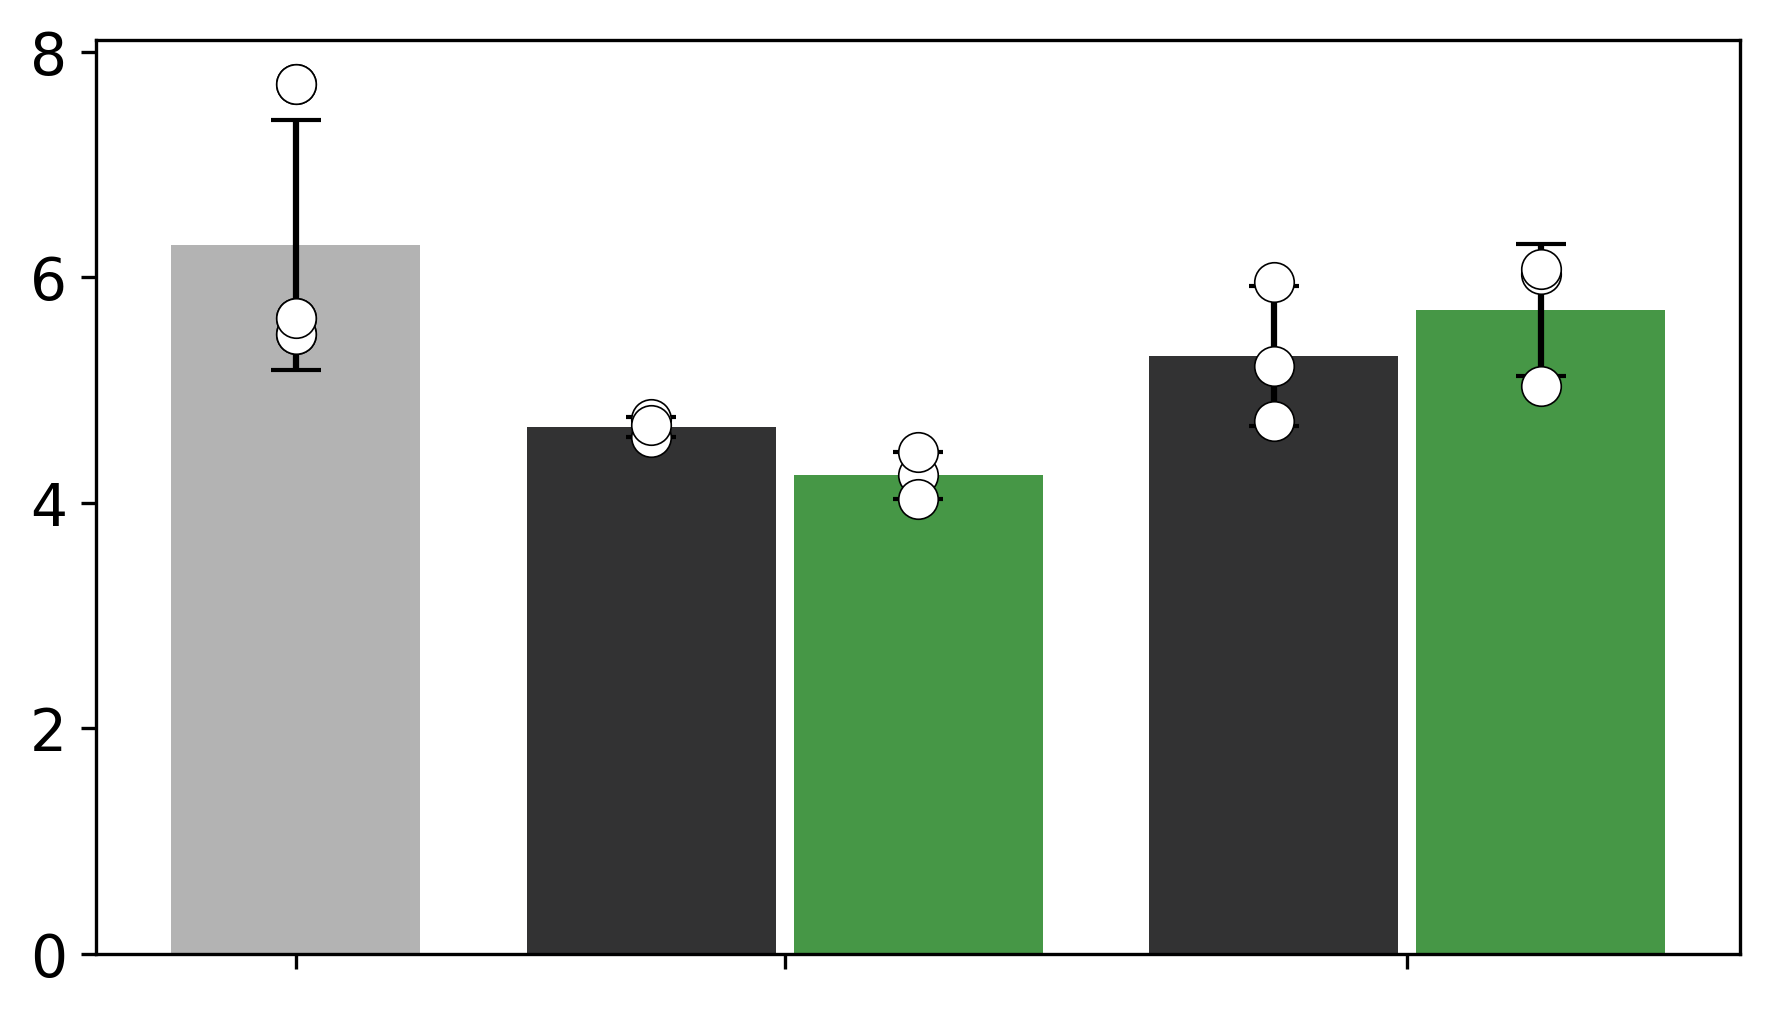

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SPLIT DATA
# -----------------------------
d0_df = skew_df[skew_df["Timepoint"] == "D0"]
post_df = skew_df[skew_df["Timepoint"] != "D0"]

# -----------------------------
# X POSITIONS (explicit + clear)
# -----------------------------
x_pos = {
    "D0": 0.0,
    "noPuro_D5": 0.4,
    "puro_D5": 0.7,
    "noPuro_D15": 1.1,
    "puro_D15": 1.4,
}

# -----------------------------
# COLORS
# -----------------------------
color_map = {
    "noPuro": "#323233",   # gray
    "puro": "#469746",     # green
}

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 3.5))

# =============================
# D0 BAR (single condition)
# =============================
d0_mean = d0_df["90/10 Skew Ratio"].mean()
d0_sd = d0_df["90/10 Skew Ratio"].std()

ax.bar(
    x_pos["D0"],
    d0_mean,
    yerr=d0_sd,
    width=0.28,
    color="0.7",
    edgecolor="none",
    capsize=6,
    zorder=2
)

ax.scatter(
    np.repeat(x_pos["D0"], len(d0_df)),
    d0_df["90/10 Skew Ratio"],
    s=90,
    facecolors="white",
    edgecolors="black",
    linewidth=0.4,
    zorder=3
)

# =============================
# D5 / D15 BARS (Condition × Timepoint)
# =============================
for (cond, tp), subdf in post_df.groupby(["Condition", "Timepoint"]):

    key = f"{cond}_{tp}"

    mean = subdf["90/10 Skew Ratio"].mean()
    sd = subdf["90/10 Skew Ratio"].std()

    ax.bar(
        x_pos[key],
        mean,
        yerr=sd,
        width=0.28,
        color=color_map[cond],
        edgecolor="none",
        capsize=6,
        zorder=2
    )

    ax.scatter(
        np.repeat(x_pos[key], len(subdf)),
        subdf["90/10 Skew Ratio"],
        s=90,
        facecolors="white",
        edgecolors="black",
        linewidth=0.4,
        zorder=3
    )

# -----------------------------
# AXES / LABELS
# -----------------------------
#ax.set_ylabel("gRNA 90/10 Skew Ratio")
ax.set_ylim(0, None)

ax.set_xticks([
    x_pos["D0"],
    np.mean([x_pos["noPuro_D5"], x_pos["puro_D5"]]),
    np.mean([x_pos["noPuro_D15"], x_pos["puro_D15"]]),
])
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(["", "", ""])



plt.tight_layout()
plt.show()

# Guide distribution
## What was the distribution of the guides in the noPuro vs DASIT conditions at D5 just based on the counts?
Do a correlation between the RPM guide counts using a spearman correlation 

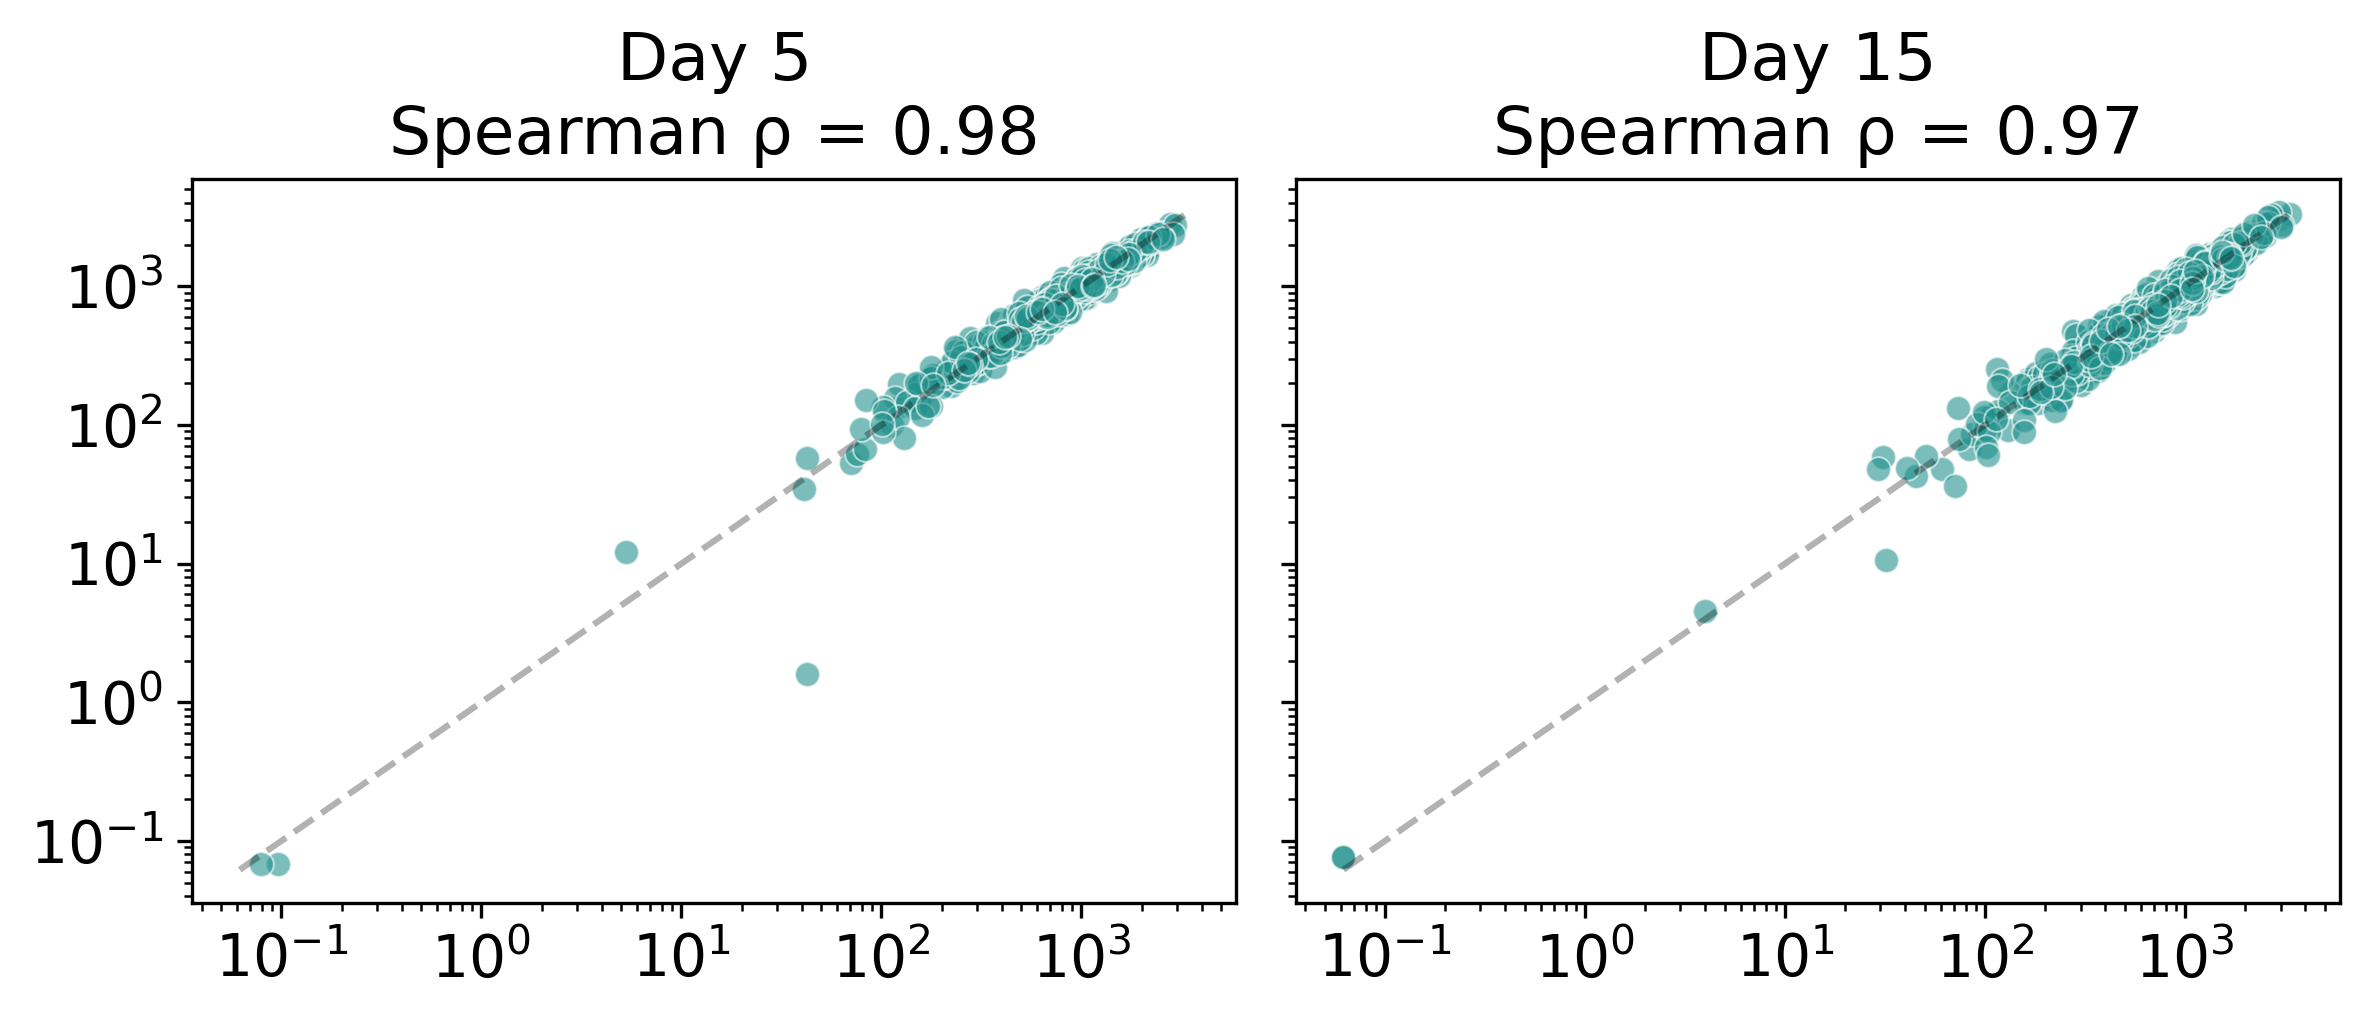

In [7]:
noPuro = pd.read_csv(OUTDIR / "noPuro_RPM", sep="\t").set_index("sgRNA")
puro   = pd.read_csv(OUTDIR / "puro_RPM", sep="\t").set_index("sgRNA")

noPuro["d5_mean"]  = noPuro[["d5_rep1","d5_rep2","d5_rep3"]].mean(axis=1)
noPuro["d15_mean"] = noPuro[["d15_rep1","d15_rep2","d15_rep3"]].mean(axis=1)

puro["d5_mean"]  = puro[["d5_rep1","d5_rep2","d5_rep3"]].mean(axis=1)
puro["d15_mean"] = puro[["d15_rep1","d15_rep2","d15_rep3"]].mean(axis=1)

aligned_d5 = pd.DataFrame({
    "noPuro": noPuro["d5_mean"],
    "puro":   puro["d5_mean"],
}).dropna()

aligned_d15 = pd.DataFrame({
    "noPuro": noPuro["d15_mean"],
    "puro":   puro["d15_mean"],
}).dropna()

plot_d5 = aligned_d5[
    (aligned_d5["noPuro"] > 0) &
    (aligned_d5["puro"] > 0)
]

plot_d15 = aligned_d15[
    (aligned_d15["noPuro"] > 0)  
    & (aligned_d15["puro"] > 0)
]

rho_d5, _  = spearmanr(plot_d5["noPuro"], plot_d5["puro"])
rho_d15, _ = spearmanr(plot_d15["noPuro"], plot_d15["puro"])

lims = (
    min(plot_d5.min().min(), plot_d15.min().min()),
    max(plot_d5.max().max(), plot_d15.max().max())
)

plt.rcParams["figure.dpi"] = 300
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True, sharey=True)

# ---- Day 5 ----
sns.scatterplot(
    ax=axes[0],
    x=plot_d5["noPuro"],
    y=plot_d5["puro"],
    s=35,
    color = sns.color_palette("viridis", 1)[0],
    alpha=0.6
)
axes[0].plot(lims, lims, "--", color="black", alpha=0.3)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].set_title(f"Day 5\nSpearman ρ = {rho_d5:.2f}", fontsize = 16)
axes[0].set_ylabel("DASIT puro mean RPM")
axes[0].tick_params(axis='x', labelsize = 14)
axes[0].tick_params(axis='y', labelsize = 14)

# ---- Day 15 ----
sns.scatterplot(
    ax=axes[1],
    x=plot_d15["noPuro"],
    y=plot_d15["puro"],
    s=35,
    color = sns.color_palette("viridis", 1)[0],
    alpha=0.6
)
axes[1].plot(lims, lims, "--", color="black", alpha=0.3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("")
axes[1].set_title(f"Day 15\nSpearman ρ = {rho_d15:.2f}", fontsize =16)
axes[1].tick_params(axis='x', labelsize = 14)

#fig.supxlabel("DASIT no puro (control) gRNA mean RPM")
#fig.suptitle(
#    "gRNA RPM correlation between DASIT and control",
#    y=0.97
#)

#removes all axes for AI figure
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    #ax.set_title("")
    

plt.tight_layout()
plt.show()


# LFC comparison
# QUESTION: should the median LFC values also be subsetted according to a certain editing threshold for comparison? 
Compare the median LFC values for each guide in the DASIT vs noPuro conditions at the end of the screen (D15)

In [8]:
puro_LFC = pd.read_csv(OUTDIR / "puro_LFC_FDR_df.csv", sep=',')
noPuro_LFC = pd.read_csv(OUTDIR / "noPuro_LFC_FDR_df.csv", sep=',')


# read in the ABE LFC data
ABE_LFC = pd.read_csv(OUTDIR / "OG_ABEscreen/ABE_LFC_FDR_df.csv", sep=',')
#remove irrelevant samples from the OG screen
exclude_terms = ["meninges", "bonemarrow", "spleen", "plasmid"]
ABE_LFC = ABE_LFC.loc[
    :,
    ~ABE_LFC.columns.str.contains("|".join(exclude_terms), case=False, regex=True)
]

In [9]:
puro_guides   = set(puro_LFC["gRNA_id"])
noPuro_guides = set(noPuro_LFC["gRNA_id"])
abe_guides    = set(ABE_LFC["gRNA_id"])

common_all = puro_guides & noPuro_guides & abe_guides

not_common = {
    "puro_only": puro_guides - (noPuro_guides | abe_guides),
    "noPuro_only": noPuro_guides - (puro_guides | abe_guides),
    "ABE_only": abe_guides - (puro_guides | noPuro_guides),
}

for k, v in not_common.items():
    print(f"\n{k} ({len(v)} guides):")
    for g in sorted(v):
        print(g)


puro_only (0 guides):

noPuro_only (0 guides):

ABE_only (0 guides):


In [10]:
print(ABE_LFC.columns.to_list())
print(puro_LFC.columns.to_list())
print(noPuro_LFC.columns.to_list())

['gRNA_id', 'Gene', 'Input_median', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5', 'p_low_unadjusted_d5', 'FDR_high_d5', 'FDR_low_d5', 'FDR_d5', 'p_high_unadjusted_d15', 'p_low_unadjusted_d15', 'FDR_high_d15', 'FDR_low_d15', 'FDR_d15']
['gRNA_id', 'Gene', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'Input_median', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5', 'p_low_unadjusted_d5', 'FDR_high_d5', 'FDR_low_d5', 'FDR_d5',

In [11]:
puro    = puro_LFC.set_index("gRNA_id")
noPuro  = noPuro_LFC.set_index("gRNA_id")
abe     = ABE_LFC.set_index("gRNA_id")

# align all on the same gRNAs
puro, noPuro = puro.align(noPuro, join="inner", axis=0)
puro, abe    = puro.align(abe, join="inner", axis=0)

In [12]:
def plot_corr(ax, x, y, xlabel, ylabel, title):
    rho = x.corr(y, method="spearman")

    color = sns.color_palette("viridis", 1)[0]


    ax.scatter(x, y, s=7, alpha=0.3, color = color)
    ax.axhline(0, ls="--", c="grey", lw=0.8)
    ax.axvline(0, ls="--", c="grey", lw=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ticks = list(range(-5, 2))  # -5, -4, -3, -2, -1, 0, 1
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    # tick label size
    ax.tick_params(axis="both", labelsize=14)
    ax.set_title(f"{title}\nSpearman ρ = {rho:.2f}", fontsize =16)

    

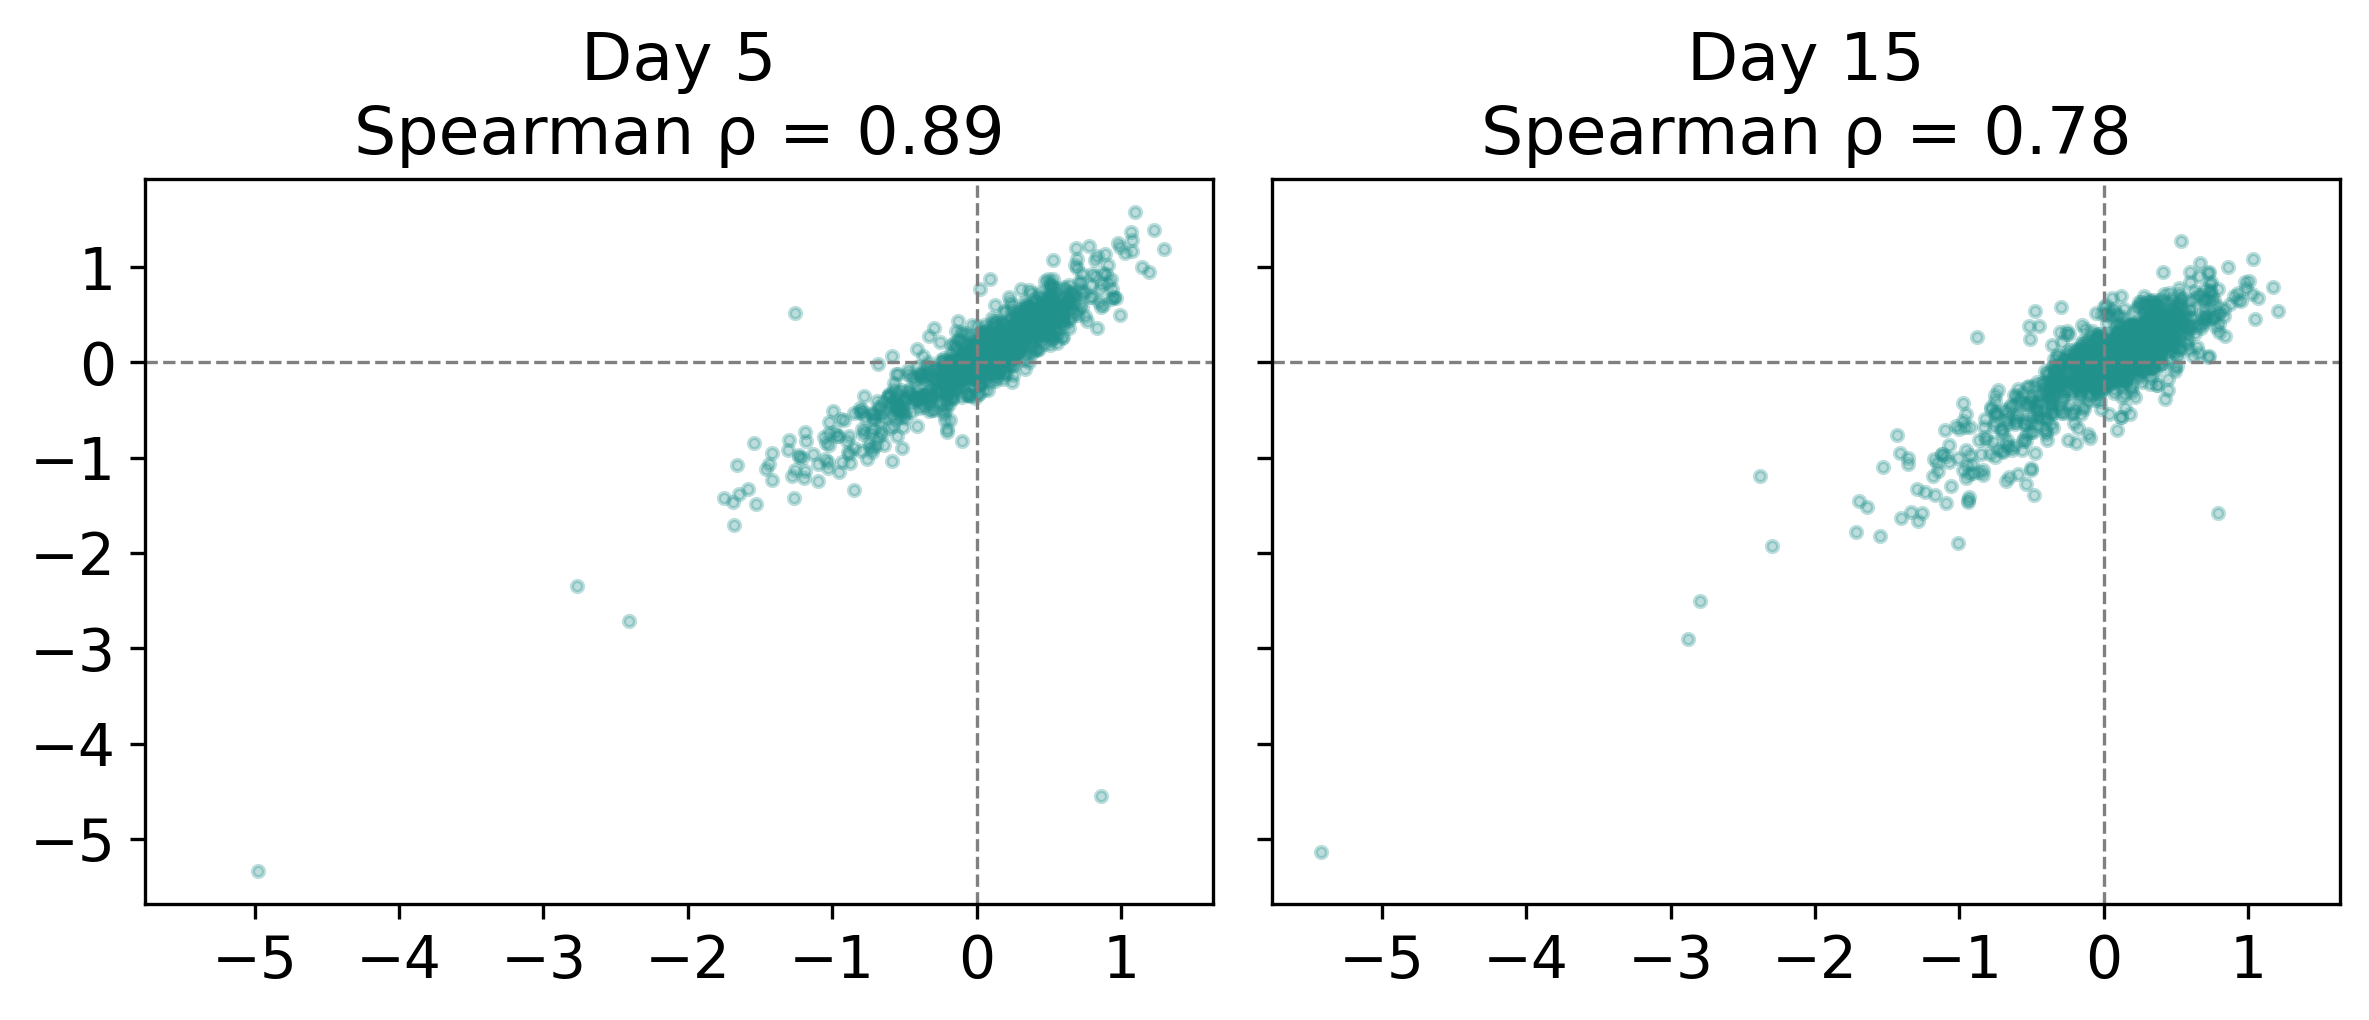

In [13]:
plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(1, 2,
    figsize=(8,3.5),
    sharex=True, sharey=True
)

# ---------- D5 ----------
plot_corr(
    axes[0],
    noPuro["LFC_median_d5"],
    puro["LFC_median_d5"],
    "",
    "",
    "Day 5"
)

# ---------- D15 ----------
plot_corr(
    axes[1],
    noPuro["LFC_median_d15"],
    puro["LFC_median_d15"],
    "",
    "",
    "Day 15"
)

#fig.suptitle(
#    "Guide-level median LFC correlation between DASIT and control (no puro)",
#   fontsize=14,
#    y=0.95
#)
#fig.supxlabel("DASIT no puro (control) gRNA LFC", fontsize=12)
#fig.supylabel("DASIT puro gRNA LFC", fontsize=12)

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_ranked_overlap(
    df1,
    df2,
    metric_col,
    gene_col="Gene",
    sgrna_col="sgRNA",
    n=20,
    label1="Dataset 1",
    label2="Dataset 2",
    figsize=(5, 5),
):
    """
    Rank–rank overlap plot for top/bottom N hits between two datasets.
    Text boxes show unique genes with overlapping sgRNA IDs.
    """

    # ---------- prepare ranked dfs ----------
    def prep(df):
        return (
            df
            .sort_values(metric_col, ascending=False)
            .reset_index(drop=True)
            .assign(rank=lambda x: x.index + 1)
        )

    d1 = prep(df1)
    d2 = prep(df2)
    total = len(d1)

    # ---------- select top & bottom ----------
    d1_hits = pd.concat([d1.head(n), d1.tail(n)])
    d2_hits = pd.concat([d2.head(n), d2.tail(n)])

    # ---------- overlap (sgRNA-level) ----------
    overlap = pd.merge(
        d1_hits[[gene_col, sgrna_col, metric_col, "rank"]],
        d2_hits[[gene_col, sgrna_col, metric_col, "rank"]],
        on=[gene_col, sgrna_col],
        suffixes=(f"_{label1}", f"_{label2}")
    )

    # ---------- classify overlap ----------
    def classify(row):
        r1 = row[f"rank_{label1}"]
        r2 = row[f"rank_{label2}"]

        if r1 <= n and r2 <= n:
            return "shared_enriched"
        if r1 > total - n and r2 > total - n:
            return "shared_depleted"
        if r1 <= n and r2 > total - n:
            return "enriched_to_depleted"
        if r1 > total - n and r2 <= n:
            return "depleted_to_enriched"
        return "other"

    overlap["category"] = overlap.apply(classify, axis=1)

    # ---------- plotting ----------
    fig, ax = plt.subplots(figsize=figsize)

    # background
    ax.scatter(
        d1["rank"],
        d2["rank"],
        s=8,
        color="lightgray",
        zorder=1
    )

    # highlighted overlap
    color_map = {
        "shared_enriched": "black",
        "shared_depleted": "black",
        "enriched_to_depleted": "red",
        "depleted_to_enriched": "red",
    }

    ax.scatter(
        overlap[f"rank_{label1}"],
        overlap[f"rank_{label2}"],
        c=overlap["category"].map(color_map),
        s=40,
        zorder=2
    )

    # guides
    ax.axvline(n, linestyle="--", color="gray", lw=1)
    ax.axvline(total - n, linestyle="--", color="gray", lw=1)
    ax.axhline(n, linestyle="--", color="gray", lw=1)
    ax.axhline(total - n, linestyle="--", color="gray", lw=1)

    # diagonal
    ax.plot([0, total], [0, total], color="lightgray", lw=2, zorder=0)

    # axes
    ax.set_xlim(0, total + 20)
    ax.set_ylim(total + 20, 0)
    ax.set_xlabel(f"{label1} rank")
    ax.set_ylabel(f"{label2} rank")
    ax.set_title(f"Ranked overlap (top/bottom {n})")

    # ---------- text box helper ----------
    def make_box(df, title):
        if df.empty:
            return f"{title}\n(none)"

        grouped = df.groupby(gene_col)
        lines = [f"{title} ({grouped.ngroups})"]

        for gene, sub in grouped:
            sgrnas = sorted(sub[sgrna_col].unique())
            lines.append(f"{gene} ({', '.join(sgrnas)})")

        return "\n".join(lines)

    # ---------- annotation boxes ----------
    top_box = make_box(
        overlap[overlap["category"] == "shared_enriched"],
        "Shared enriched"
    )

    bottom_box = make_box(
        overlap[overlap["category"] == "shared_depleted"],
        "Shared depleted"
    )

    ax.text(
        0.02, 0.98,
        top_box,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
    )

    ax.text(
        0.98, 0.02,
        bottom_box,
        transform=ax.transAxes,
        va="bottom",
        ha="right",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    return overlap


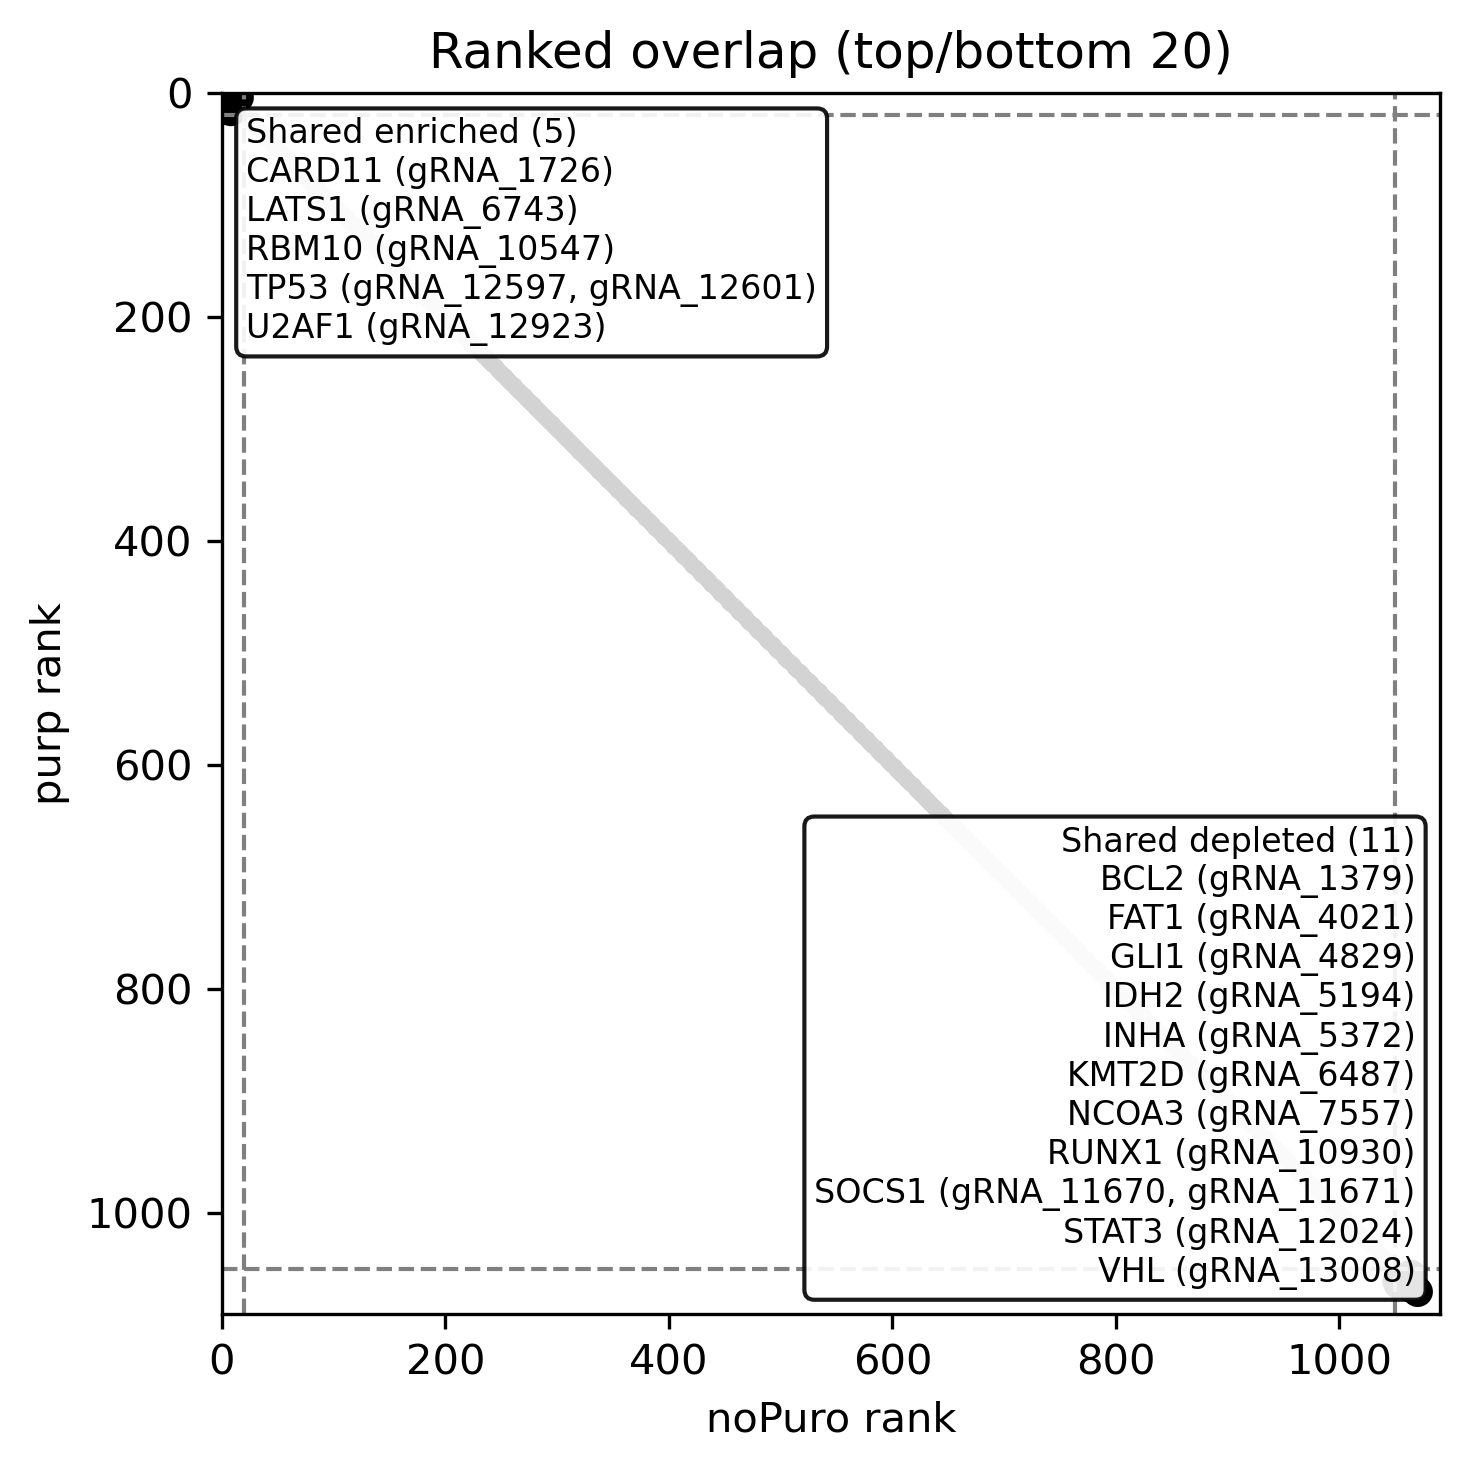

,Gene,gRNA_id,LFC_median_d15_noPuro,rank_noPuro,LFC_median_d15_purp,rank_purp,category
0,TP53,gRNA_12597,1.170432,2,0.794501,15,shared_enriched
1,LATS1,gRNA_6743,1.031502,5,1.084118,2,shared_enriched
2,RBM10,gRNA_10547,1.008652,7,0.849601,10,shared_enriched
3,TP53,gRNA_12601,0.986225,8,0.784452,16,shared_enriched
4,U2AF1,gRNA_12923,0.977054,9,0.846402,11,shared_enriched
5,CARD11,gRNA_1726,0.861562,15,1.004860,4,shared_enriched
6,KMT2D,gRNA_6487,-1.261177,1052,-1.575417,1060,shared_depleted
7,NCOA3,gRNA_7557,-1.287471,1053,-1.661388,1063,shared_depleted
8,SOCS1,gRNA_11670,-1.335769,1055,-1.574980,1059,shared_depleted
9,STAT3,gRNA_12024,-1.401803,1058,-1.635264,1062,shared_depleted


In [15]:
plot_ranked_overlap(noPuro_LFC, puro_LFC, metric_col="LFC_median_d15", gene_col="Gene", sgrna_col="gRNA_id", n = 20, label1="noPuro", label2="purp")

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

def plot_lfc_correlation_with_hits(
    df1,
    df2,
    metric_col="LFC_median_d15",
    gene_col="Gene",
    sgrna_col="sgRNA",
    n=20,
    label1="Dataset 1",
    label2="Dataset 2",
    figsize=(5, 5),
):
    """
    Scatter plot of LFC vs LFC between two datasets at the gRNA level,
    highlighting and labeling overlapping top/bottom N ranked guides.
    """

    # ---- rank guides in each dataset ----
    def prep(df):
        return (
            df
            .sort_values(metric_col, ascending=False)
            .reset_index(drop=True)
            .assign(rank=lambda x: x.index + 1)
        )

    d1 = prep(df1)
    d2 = prep(df2)
    total = len(d1)

    # ---- merge on sgRNA (true guide overlap) ----
    merged = pd.merge(
        d1[[gene_col, sgrna_col, metric_col, "rank"]],
        d2[[gene_col, sgrna_col, metric_col, "rank"]],
        on=[gene_col, sgrna_col],
        suffixes=(f"_{label1}", f"_{label2}")
    )

    # ---- define top/bottom hit overlap ----
    merged["hit_category"] = "background"

    top_mask = (
        (merged[f"rank_{label1}"] <= n) &
        (merged[f"rank_{label2}"] <= n)
    )

    bottom_mask = (
        (merged[f"rank_{label1}"] > total - n) &
        (merged[f"rank_{label2}"] > total - n)
    )

    merged.loc[top_mask, "hit_category"] = "shared_enriched"
    merged.loc[bottom_mask, "hit_category"] = "shared_depleted"

    # ---- correlation ----
    rho, pval = spearmanr(
        merged[f"{metric_col}_{label1}"],
        merged[f"{metric_col}_{label2}"]
    )

    # ---- plotting ----
    fig, ax = plt.subplots(figsize=figsize)

    # background
    ax.scatter(
        merged[f"{metric_col}_{label1}"],
        merged[f"{metric_col}_{label2}"],
        s=12,
        color="lightgray",
        alpha=0.6,
        zorder=1
    )

    # highlighted hits
    palette = sns.color_palette("viridis", 10)

    color_map = {
        "shared_depleted": palette[2],   # dark blue / purple
        "shared_enriched": palette[8],   # yellow-green
    }

    for cat, color in color_map.items():
        sub = merged[merged["hit_category"] == cat]
        ax.scatter(
            sub[f"{metric_col}_{label1}"],
            sub[f"{metric_col}_{label2}"],
            s=40,
            color=color,
            edgecolor="black",
            zorder=2,
            label=cat.replace("_", " ")
        )

    # ---- label highlighted guides only ----
    label_df = merged[merged["hit_category"] != "background"]

    for _, row in label_df.iterrows():
        label = f"{row[gene_col]} ({row[sgrna_col]})"
        ax.text(
            row[f"{metric_col}_{label1}"] + 0.02,
            row[f"{metric_col}_{label2}"] + 0.02,
            label,
            fontsize=6,
            alpha=0.9
        )

    # ---- formatting ----
    ax.axhline(0, color="black", lw=1, linestyle="--")
    ax.axvline(0, color="black", lw=1, linestyle="--")

    ax.set_xlabel(f"{label1} {metric_col}")
    ax.set_ylabel(f"{label2} {metric_col}")
    ax.set_title(
        f"LFC correlation (ρ={rho:.2f})\nTop/bottom {n} shared guides"
    )

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return merged.sort_values("hit_category")


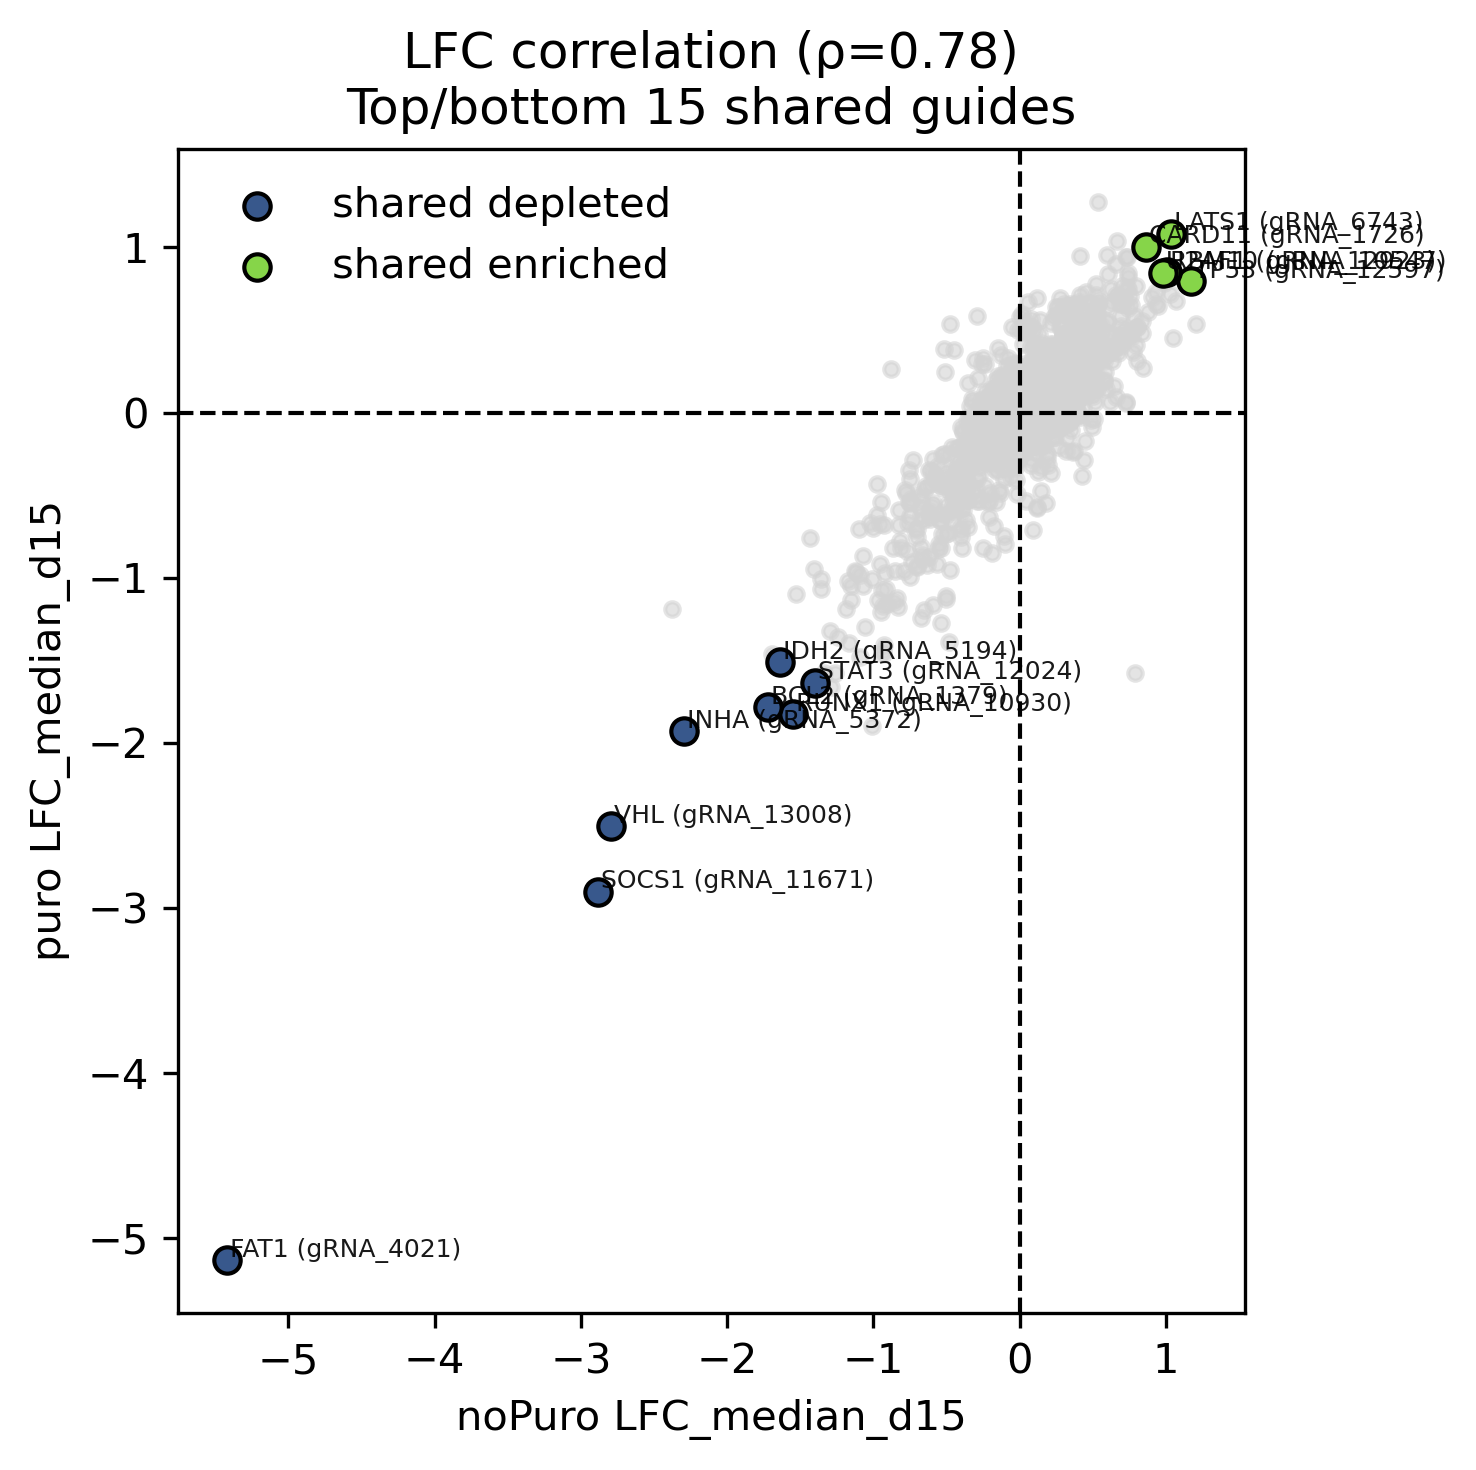

In [17]:
merged = plot_lfc_correlation_with_hits(
    noPuro_LFC,
    puro_LFC,
    metric_col="LFC_median_d15",
    gene_col="Gene",
    sgrna_col="gRNA_id",
    n=15,
    label1="noPuro",
    label2="puro"
)


0        True
1       False
2        True
3        True
4        True
        ...  
1065     True
1066     True
1067     True
1068     True
1069     True
Name: d0_rep1, Length: 1070, dtype: bool
99.25233644859813
0       True
1       True
2       True
3       True
4       True
        ... 
1065    True
1066    True
1067    True
1068    True
1069    True
Name: d0_rep2, Length: 1070, dtype: bool
99.34579439252337
0        True
1       False
2        True
3        True
4        True
        ...  
1065     True
1066     True
1067     True
1068     True
1069     True
Name: d0_rep3, Length: 1070, dtype: bool
98.97196261682242
0       True
1       True
2       True
3       True
4       True
        ... 
1065    True
1066    True
1067    True
1068    True
1069    True
Name: d5_rep1, Length: 1070, dtype: bool
98.97196261682242
0       True
1       True
2       True
3       True
4       True
        ... 
1065    True
1066    True
1067    True
1068    True
1069    True
Name: d5_rep2, Length: 1070

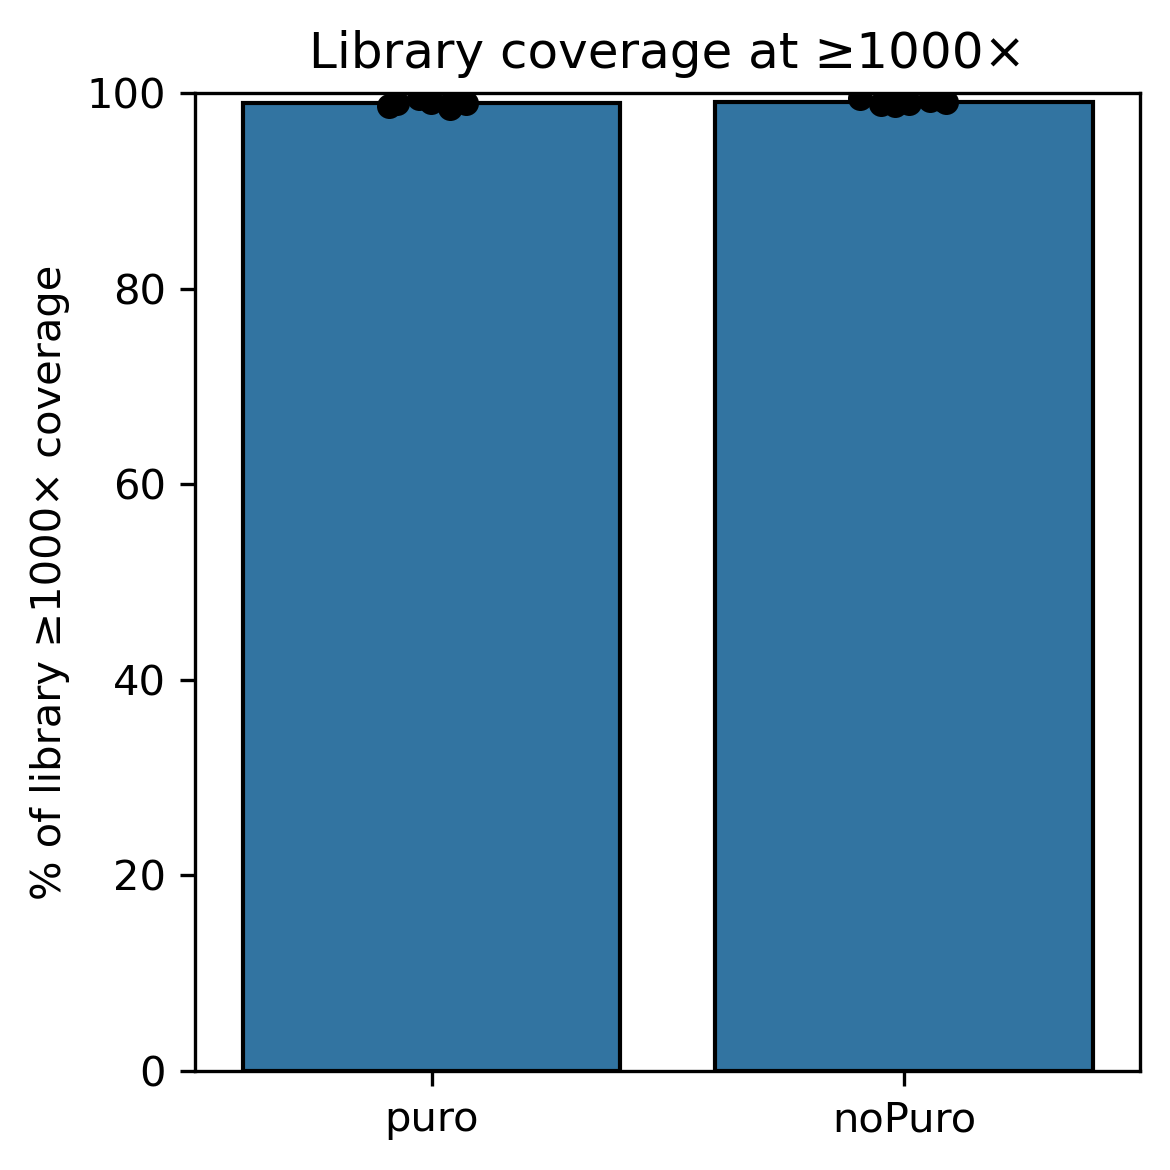

In [19]:


# Load counts
puro_counts = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t")
noPuro_counts = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t")

# Drop metadata columns (adjust if needed)
puro_counts = puro_counts[puro_counts.columns[2:]]
noPuro_counts = noPuro_counts[noPuro_counts.columns[2:]]

threshold = 1000

def percent_above_threshold(count_df, condition):
    records = []
    for sample in count_df.columns:
        pct = (count_df[sample] >= threshold).mean() * 100
        print(count_df[sample] >= threshold)
        print(pct)
        records.append({
            "Sample": sample,
            "Condition": condition,
            "Percent_1000x": pct
        })
    return pd.DataFrame(records)

puro_pct = percent_above_threshold(puro_counts, "puro")
noPuro_pct = percent_above_threshold(noPuro_counts, "noPuro")

pct_df = pd.concat([puro_pct, noPuro_pct], ignore_index=True)

print(pct_df)

plt.figure(figsize=(4,4))

sns.barplot(
    data=pct_df,
    x="Condition",
    y="Percent_1000x",
    edgecolor="black",
    ci="sd"
)

sns.stripplot(
    data=pct_df,
    x="Condition",
    y="Percent_1000x",
    color="black",
    size=6,
    jitter=True
)

plt.ylabel("% of library ≥1000× coverage")
plt.xlabel("")
plt.title("Library coverage at ≥1000×")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()



Guides passing edit filter: 836
Guides passing edit filter: 849
Counts after filtering:
puro: (849, 10)
noPuro: (836, 10)


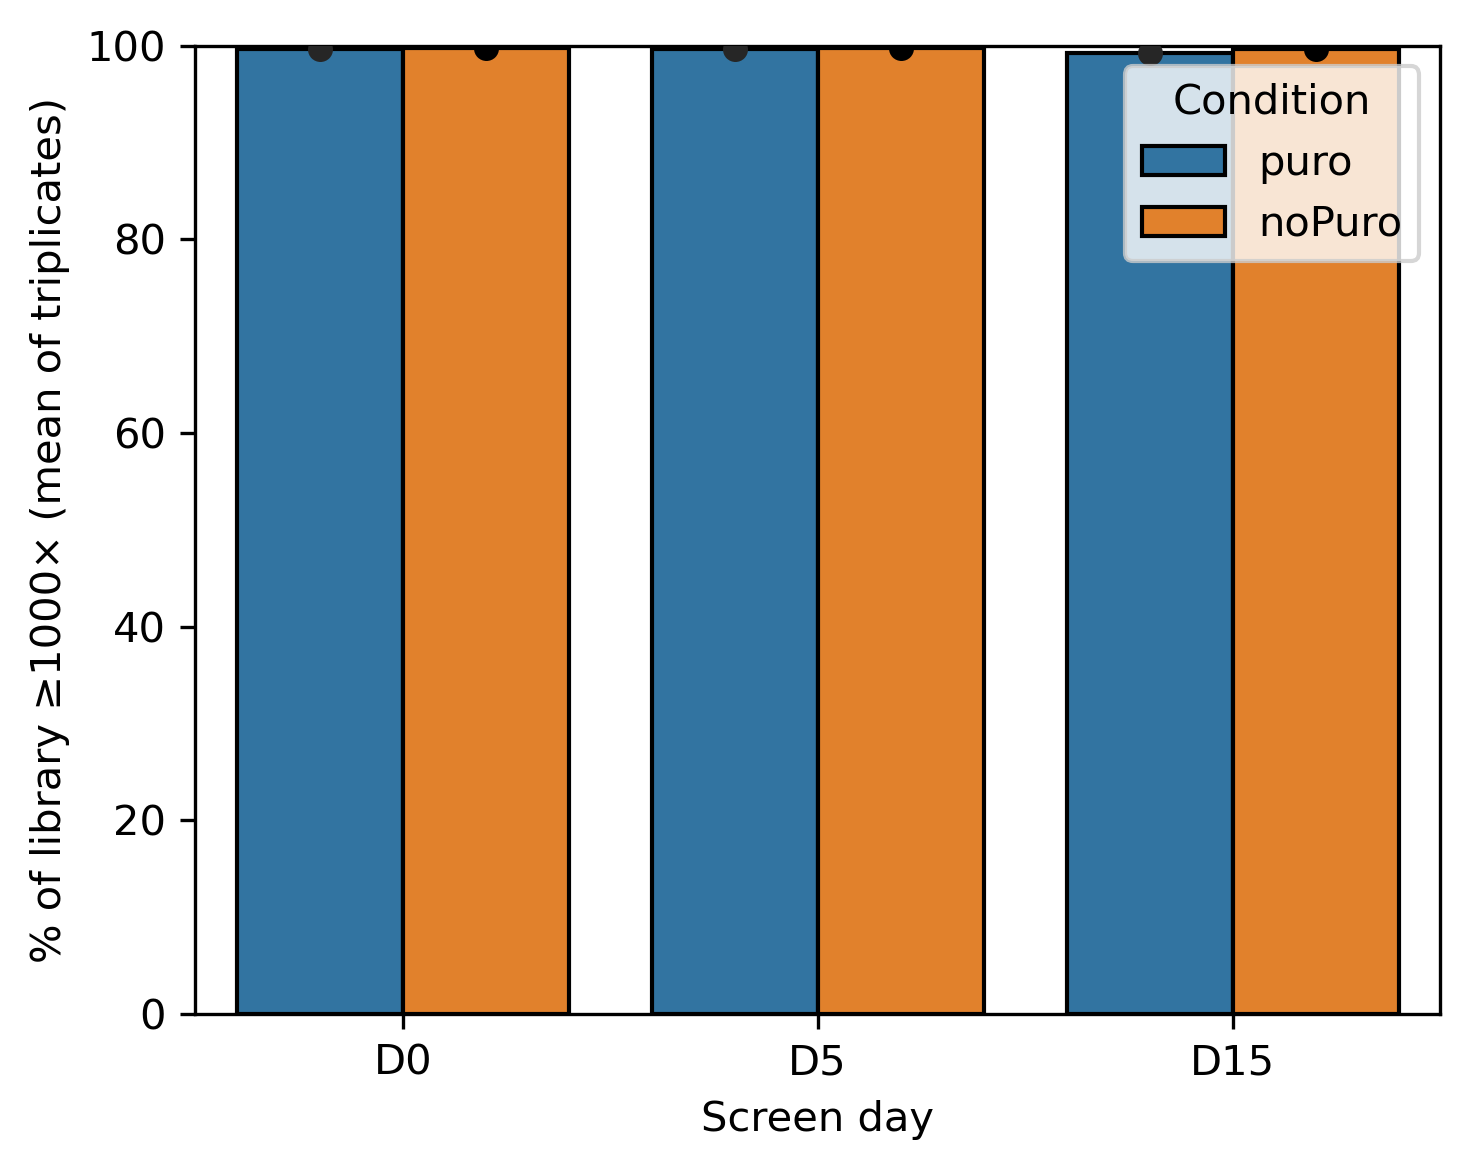

In [20]:
# load editing information
edit_df_puro = pd.read_csv(OUTDIR / "puro_LFC_FDR_df.csv", sep=",")
edit_df_nopuro = pd.read_csv(OUTDIR / "noPuro_LFC_FDR_df.csv", sep=",")

# keep only guides with >=20% target base editing
edit_guides_nopuro = (
    edit_df_nopuro
    .loc[edit_df_nopuro["target_base_edit_perc"] >= 20, "gRNA_id"]
    .astype(str)
)
edit_guides_nopuro = set(edit_guides_nopuro)
print(f"Guides passing edit filter: {len(edit_guides_nopuro)}")

edit_guides_puro = (
    edit_df_puro
    .loc[edit_df_puro["target_base_edit_perc"] >= 20, "gRNA_id"]
    .astype(str)
)
edit_guides_puro = set(edit_guides_puro)
print(f"Guides passing edit filter: {len(edit_guides_puro)}")

puro_counts = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t", index_col=0)
noPuro_counts = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t", index_col=0)

puro_counts_filt = puro_counts.loc[puro_counts.index.isin(edit_guides_puro)]
noPuro_counts_filt = noPuro_counts.loc[noPuro_counts.index.isin(edit_guides_nopuro)]

print("Counts after filtering:")
print("puro:", puro_counts_filt.shape)
print("noPuro:", noPuro_counts_filt.shape)

rep_groups = {
    "D0":  ["d0_rep1", "d0_rep2", "d0_rep3"],
    "D5":  ["d5_rep1", "d5_rep2", "d5_rep3"],
    "D15": ["d15_rep1", "d15_rep2", "d15_rep3"],
}

threshold = 1000

def percent_above_threshold_by_day(count_df, condition):
    records = []

    for day, reps in rep_groups.items():
        # mean coverage per guide across triplicates
        mean_cov = count_df[reps].mean(axis=1)

        pct = (mean_cov >= threshold).mean() * 100

        records.append({
            "Day": day,
            "Condition": condition,
            "Percent_1000x": pct
        })

    return pd.DataFrame(records)

puro_pct = percent_above_threshold_by_day(puro_counts_filt, "puro")
noPuro_pct = percent_above_threshold_by_day(noPuro_counts_filt, "noPuro")

pct_df = pd.concat([puro_pct, noPuro_pct], ignore_index=True)

plt.figure(figsize=(5,4))

sns.barplot(
    data=pct_df,
    x="Day",
    y="Percent_1000x",
    hue="Condition",
    order=["D0", "D5", "D15"],
    edgecolor="black",
    ci=None
)

sns.stripplot(
    data=pct_df,
    x="Day",
    y="Percent_1000x",
    hue="Condition",
    order=["D0", "D5", "D15"],
    dodge=True,
    color="black",
    size=6,
    legend=False
)

plt.ylabel("% of library ≥1000× (mean of triplicates)")
plt.xlabel("Screen day")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

